## All the President's Speeches 

As we learned on Friday, word frequency distribution is an intuitive way of determining the major themes, topics, or even preoccupations of the speech giver. Pull texts from different US presidents and use FreqDist() to gain insights into the data. This is a fairly open assignment. The goal is to identify something interesting! Pull the text, tokenize, remove stopwords, and plot the frequency of the words. That's the technical part. But much of this assignment is your ability to use word frequency to gain insights comparatively, intra or inter presidents. Let the python notebook from our lecture be your guide! The more interesting and creative the analysis, the more points you will receive. We might pick one student's analysis to be displayed in lecture, and that person will receive bonus credit for the work.

In [11]:
import nltk

In [12]:
from nltk import FreqDist

In [13]:
from nltk.tokenize import word_tokenize
from nltk.corpus import inaugural
from nltk.corpus import stopwords
stop_words = nltk.corpus.stopwords.words("english")
import matplotlib.pyplot as plt # Chat suggested I do this to do more complex graphing
import string

In [14]:
print(inaugural.fileids())

['1789-Washington.txt', '1793-Washington.txt', '1797-Adams.txt', '1801-Jefferson.txt', '1805-Jefferson.txt', '1809-Madison.txt', '1813-Madison.txt', '1817-Monroe.txt', '1821-Monroe.txt', '1825-Adams.txt', '1829-Jackson.txt', '1833-Jackson.txt', '1837-VanBuren.txt', '1841-Harrison.txt', '1845-Polk.txt', '1849-Taylor.txt', '1853-Pierce.txt', '1857-Buchanan.txt', '1861-Lincoln.txt', '1865-Lincoln.txt', '1869-Grant.txt', '1873-Grant.txt', '1877-Hayes.txt', '1881-Garfield.txt', '1885-Cleveland.txt', '1889-Harrison.txt', '1893-Cleveland.txt', '1897-McKinley.txt', '1901-McKinley.txt', '1905-Roosevelt.txt', '1909-Taft.txt', '1913-Wilson.txt', '1917-Wilson.txt', '1921-Harding.txt', '1925-Coolidge.txt', '1929-Hoover.txt', '1933-Roosevelt.txt', '1937-Roosevelt.txt', '1941-Roosevelt.txt', '1945-Roosevelt.txt', '1949-Truman.txt', '1953-Eisenhower.txt', '1957-Eisenhower.txt', '1961-Kennedy.txt', '1965-Johnson.txt', '1969-Nixon.txt', '1973-Nixon.txt', '1977-Carter.txt', '1981-Reagan.txt', '1985-Reaga

1789-Washington.txt
Total unity mentions: 38
Total conflict mentions: 4

1793-Washington.txt
Total unity mentions: 4
Total conflict mentions: 0

1797-Adams.txt
Total unity mentions: 75
Total conflict mentions: 11

1801-Jefferson.txt
Total unity mentions: 60
Total conflict mentions: 9

1805-Jefferson.txt
Total unity mentions: 52
Total conflict mentions: 9

1809-Madison.txt
Total unity mentions: 28
Total conflict mentions: 6

1813-Madison.txt
Total unity mentions: 31
Total conflict mentions: 27

1817-Monroe.txt
Total unity mentions: 100
Total conflict mentions: 41

1821-Monroe.txt
Total unity mentions: 120
Total conflict mentions: 54

1825-Adams.txt
Total unity mentions: 113
Total conflict mentions: 26

1829-Jackson.txt
Total unity mentions: 27
Total conflict mentions: 6

1833-Jackson.txt
Total unity mentions: 46
Total conflict mentions: 5

1837-VanBuren.txt
Total unity mentions: 92
Total conflict mentions: 25

1841-Harrison.txt
Total unity mentions: 226
Total conflict mentions: 32

1845

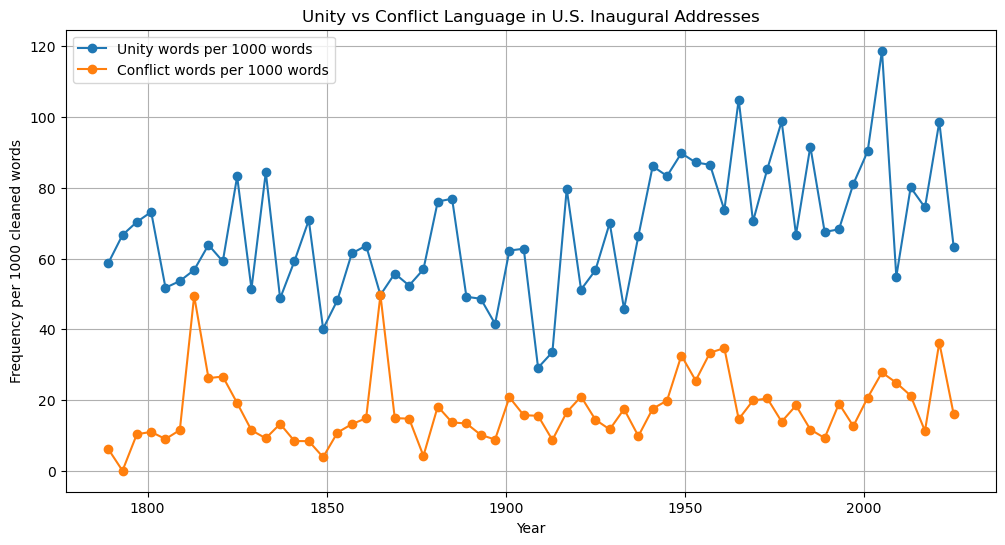

In [25]:
1. #Your code here:
unity_words = [
    "union", "unity", "unite", "united", "together", "common", "shared",
    "share", "joined", "join", "solidarity", "harmony", "peace", "accord",
    "cooperation", "cooperate", "mutual", "collective", "community",
    "communities", "nation", "national", "people", "citizens", "americans",
    "fellow", "brotherhood", "sisterhood", "friendship", "friends",
    "partnership", "partnerships", "alliance", "alliances", "one",
    "whole", "bond", "bonds", "trust", "faith", "hope", "charity",
    "goodwill", "reconciliation", "reconcile", "liberty", "freedom",
    "justice", "equal", "equality", "rights", "democracy", "republic"
]

conflict_words = [
    "war", "wars", "battle", "battles", "fight", "fights", "fighting",
    "struggle", "struggles", "strife", "conflict", "conflicts", "enemy",
    "enemies", "foe", "foes", "threat", "threats", "danger", "dangers",
    "peril", "perils", "crisis", "crises", "attack", "attacks", "assault",
    "defend", "defense", "defence", "secure", "security", "armed",
    "force", "forces", "violence", "violent", "division", "divisions",
    "divide", "divided", "discord", "hostility", "hostilities", "fear",
    "terror", "terrorism", "tyranny", "oppression", "oppressed",
    "chaos", "burden", "sacrifice", "blood", "storm", "confront",
    "confrontation", "combat"
]

stop_words = set(stopwords.words("english"))

years = []
unity_freqs = []
conflict_freqs = []

for file in inaugural.fileids():
    year = int(file[:4])
    words = inaugural.words(file)

    clean_words = []
    for word in words:
        word = word.lower()
        if word.isalpha() and word not in stop_words:
            clean_words.append(word)

    unity_count = 0
    conflict_count = 0

    for word in clean_words:
        if word in unity_words:
            unity_count += 1
        if word in conflict_words:
            conflict_count += 1

    total_words = len(clean_words)
    unity_per_1000 = unity_count / total_words * 1000
    conflict_per_1000 = conflict_count / total_words * 1000

    years.append(year)
    unity_freqs.append(unity_per_1000)
    conflict_freqs.append(conflict_per_1000)

    print(file)
    print("Total unity mentions:", unity_count)
    print("Total conflict mentions:", conflict_count)
    print()

plt.figure(figsize=(12,6))
plt.plot(years, unity_freqs, marker='o', label='Unity words per 1000 words')
plt.plot(years, conflict_freqs, marker='o', label='Conflict words per 1000 words')

plt.xlabel('Year')
plt.ylabel('Frequency per 1000 cleaned words')
plt.title('Unity vs Conflict Language in U.S. Inaugural Addresses')
plt.legend()
plt.grid(True)
plt.show()

# This is fascinating and not what I expected, although intuitive upon reflection.
# It looks like these words are loosely positively correlated. My expectations that there would be comparable volumes
# of each word was misplaced (which, again, makes perfect sense), and my guess that certain presidents in certain eras
# would have lots of conflict words and few unity is equally misplaced.
# I need much greater nuance to capture speeches that truly embody unity vs division.

## Words to Vectors
The word-count model is useful because it is simple, transparent, and easy to teach. But it is a very crude sensor. A vector-similarity framing gets much closer to what you likely actually care about:

not whether the exact token “liberty” appears,
but whether the speech is semantically near the concept of liberty.

That is a much better statement of the problem.

Why vector similarity may be better

A count-based model assumes:

idea ≈ exact word
meaning is stable over time
synonyms do not matter much
rhetoric is directly observable through lexical frequency

Those assumptions are weak.

A vector approach instead says:

each sentence, paragraph, or speech can be embedded as a vector
the concept “liberty” can also be represented as a vector
ideological signal is proximity in semantic space

What the vector version changes

With vector similarity, your observation is no longer a count. It becomes a continuous score.
​


A president can talk at length about liberty without ever saying “liberty.”

Your count model misses that entirely.

But there are real problems

This is where the vector story gets more serious.

1. Embeddings are not historically neutral

A modern embedding model may not represent 1790 or 1860 language properly.

“Liberty” in 1801, “freedom” in 1865, and “democracy” in 2009 may cluster differently depending on the model and training corpus.

So vector similarity can quietly import present-day semantics into historical text.

That is a major issue.

2. Concept vectors are slippery

What exactly is the vector for “liberty”?

Is it:

the embedding of the single word “liberty”?
the average embedding of a hand-built definition?
the centroid of example passages?
a contrastive dimension versus “authority” or “order”?

That choice matters a lot.

3. Similarity is not the same as endorsement

A speech may be semantically close to liberty because it is criticizing it, qualifying it, or subordinating it.

Similarity detects topical proximity, not stance.

4. Interpretability drops

“Count of liberty per 1,000 words” is easy to explain.

“Average cosine similarity between sentence embeddings and a constructed liberty centroid” is much harder to defend to a skeptical audience.

the neural network learns to associate words that appear in similar contexts with similar vector representations in the vector space.

Word2vec is a popular machine learning algorithm for generating word embeddings, which are numerical representations of words in a high-dimensional vector space. The algorithm was developed by Google researchers Tomas Mikolov, Kai Chen, Greg Corrado, and Jeffrey Dean in 2013.

The main idea behind word2vec is to use a neural network to learn the vector representations of words based on the context in which they appear in a large corpus of text. The algorithm has two different architectures: continuous bag-of-words (CBOW) and skip-gram.

In the CBOW architecture, the algorithm tries to predict the current word based on a window of surrounding words. In the skip-gram architecture, the algorithm tries to predict the surrounding words based on the current word. In both cases, the neural network learns to associate words that appear in similar contexts with similar vector representations in the vector space.

The resulting word embeddings can be used in a variety of natural language processing (NLP) tasks, such as text classification, sentiment analysis, and machine translation. One of the key benefits of word embeddings is that they can capture semantic relationships between words, such as synonyms, antonyms, and analogies. For example, in the vector space learned by word2vec, the vector for "king" might be close to the vector for "queen", and the vector for "man" might be close to the vector for "woman".



Word2vec helps us understand how words are related to each other. You can think of it like a game where you try to guess which words are often used together.

For example, imagine you're reading a story about a cat who goes on an adventure. The words "cat" and "adventure" often appear together in the story. Word2vec learns from these patterns and puts the words "cat" and "adventure" closer together in a big list of all the words in the story.

Word2vec can also help us understand how words are related in other ways. For instance, it can figure out that "king" and "queen" are related words, just like "man" and "woman". It does this by looking at how often these words appear together in lots of different texts.

So, word2vec helps us understand how words are related and can help us make predictions about which words might appear together in a sentence or paragraph. This is useful in many different areas, like understanding how people talk about products in reviews or how people talk about politics on social media.

Watch this video:
https://www.youtube.com/watch?v=iErmK_sJtag


In [29]:
!pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ------ --------------------------------- 3.9/24.4 MB 23.6 MB/s eta 0:00:01
   --------------- ------------------------ 9.7/24.4 MB 26.5 MB/s eta 0:00:01
   ---------------------------- ----------- 17.3/24.4 MB 30.6 MB/s eta 0:00:01
   ---------------------------------------  24.4/24.4 MB 31.4 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 27.3 MB/s  0:00:00

   ---------------------------------------- 0/2 [smart_open]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------- ------------------- 1/2 [gensim]
   -------------------

In [20]:
from gensim.models import Word2Vec
from nltk.corpus import stopwords
from string import punctuation 
from nltk.corpus import gutenberg
import pprint
pp = pprint.PrettyPrinter()

In [21]:
bible_sents = gutenberg.sents('bible-kjv.txt')
sw = stopwords.words('english')
bible = [[w.lower() for w in s if w not in punctuation and w not in sw] for s in bible_sents]
print(len(bible))

bible_vec = Word2Vec(bible)
pp.pprint(bible_vec.wv.most_similar('god', topn=8))

30103
[('mercy', 0.9344609379768372),
 ('truth', 0.905815601348877),
 ('salvation', 0.8945131301879883),
 ('grace', 0.890990674495697),
 ('bless', 0.878956139087677),
 ('hosts', 0.8758916854858398),
 ('glory', 0.8744763135910034),
 ('righteousness', 0.86949622631073)]


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [22]:
pp.pprint(bible_vec.wv.most_similar('devil', topn=8))

[('hard', 0.9796145558357239),
 ('dishonour', 0.9779117107391357),
 ('somewhat', 0.9768885374069214),
 ('pleasures', 0.9759845733642578),
 ('rend', 0.9754500389099121),
 ('hitherto', 0.9743115901947021),
 ('changed', 0.9735854864120483),
 ('beautiful', 0.9730671644210815)]


In [23]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Define the two paragraphs
paragraph1 = """
Bees are flying insects closely related to wasps and ants, known for their role in pollination and, in the case of the best-known bee species, the western honey bee, for producing honey. Bees are a monophyletic lineage within the superfamily Apoidea. They are presently considered a clade, called Anthophila. There are over 16,000 known species of bees in seven recognized biological families. Some species – including honey bees, bumblebees, and stingless bees – are solitary, but most bees are social insects, forming colonies that contain many individuals. The most common type of bee found in homes is the honey bee, but there are over 4,000 different species of bees. Other types of bees include carpenter bees, which burrow into wood to lay their eggs, and mining bees, which live underground. Bees range in size from tiny stingless bee species whose workers are less than 2 millimeters (0.08 in) long, to Megachile pluto, the largest species of leafcutter bee, whose females can attain a length of 39 millimeters (1.54 in). The most common bees in the Northern Hemisphere are the Halictidae, or sweat bees, but they are small and often mistaken for wasps or flies.
"""

paragraph2 = "According to all known laws of aviation, there is no way a bee should be able to fly."
# Preprocess the text data
# You may need additional preprocessing steps depending on your data
# For now, we'll keep it simple by converting all text to lowercase
paragraph1 = paragraph1.lower()
paragraph2 = paragraph2.lower()

# Vectorize the text using CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform([paragraph1, paragraph2])

# Compute the similarity between the vectors
similarity_score = cosine_similarity(X)
print("Similarity Score between the two paragraphs:", similarity_score[0,1])


Similarity Score between the two paragraphs: 0.20642132338700137


## Sentiment Analysis
What is sentiment analysis? Sentiment analysis is a process of using natural language processing, machine learning, and computational linguistics to analyze the attitudes, opinions, and emotions expressed in text data. The goal of sentiment analysis is to determine the sentiment, or emotional tone, of a piece of text, which can be positive, negative, or neutral. Sentiment analysis can be applied to a wide range of text data, including social media posts, product reviews, news articles, and customer feedback. The results of sentiment analysis can be used to gain insights into customer satisfaction, brand reputation, and public opinion on various topics.




In [39]:
!pip install vaderSentiment

In [26]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()


Working and Scoring
Let's test our first sentiment using VADER now. We will use the polarity_scores( ) method to obtain the polatiry indices for the given sentence:

In [27]:
sentence = "I love that movie!"
score = analyzer.polarity_scores(sentence)
print(score)

{'neg': 0.0, 'neu': 0.4, 'pos': 0.6, 'compound': 0.6696}


In [28]:
sentence2 = "OMG, I freaked out when I saw it!"
score = analyzer.polarity_scores(sentence2)
print(score)


{'neg': 0.263, 'neu': 0.737, 'pos': 0.0, 'compound': -0.3595}


In [29]:
sentence3 = "OMG, this job totally SUX!!"
score = analyzer.polarity_scores(sentence3)
print(score)

{'neg': 0.507, 'neu': 0.493, 'pos': 0.0, 'compound': -0.6261}


In [30]:
sentence4 = '😀' #command+control+space brings up emoji'
score = analyzer.polarity_scores(sentence4)
print(score)

{'neg': 0.0, 'neu': 0.286, 'pos': 0.714, 'compound': 0.3612}


In [31]:
sentence5 = '😀 😀 😀 😀 😀' #command+control+space brings up emoji'
score = analyzer.polarity_scores(sentence5)
print(score)

{'neg': 0.0, 'neu': 0.286, 'pos': 0.714, 'compound': 0.8885}


In [32]:
sentence6 = '😢'
score = analyzer.polarity_scores(sentence6)
print(score)

{'neg': 0.756, 'neu': 0.244, 'pos': 0.0, 'compound': -0.4767}


In [33]:
sentence7 = 'That movie was 💩'
score = analyzer.polarity_scores(sentence6)
print(score)

{'neg': 0.756, 'neu': 0.244, 'pos': 0.0, 'compound': -0.4767}


In [34]:
!pip install textblob
from textblob import TextBlob
lincoln = inaugural.raw('1861-Lincoln.txt')

# Define the text passage to analyze
text = lincoln
# Perform tone analysis on the text passage
blob = TextBlob(text)
polarity = blob.sentiment.polarity
subjectivity = blob.sentiment.subjectivity

# Print the tone analysis results
if polarity > 0:
    print("The text is more positive than negative.")
elif polarity < 0:
    print("The text is more negative than positive.")
else:
    print("The text is neutral.")
    
if subjectivity > 0.5:
    print("The text is more subjective than objective.")
else:
    print("The text is more objective than subjective.")

The text is more positive than negative.
The text is more subjective than objective.


2. How is text blob different than Vader? When would I use Text Blob? When Vader?
Your answer here:
Text blob provides metrics for sentiment and how opinionated writing is, specifically scoring polarity (positive vs negative) and subjectivity (how factual vs opinion-based language seems). Vader, on the other hand, focuses exclusively on sentiment, ranking how positive, negative, or neutral a phrase is by aggregating scores across each word. Vader also uses rules for negation, emphasis, capitalization, and punctuation. I would use Text Blob when looking at something like a news source, analyzing an opinion piece to understand its perspective. I would use Vader when analyzing how someone feels about something. For instance, if I knew about these while coding my Bipolar Disorder app, I would have used Vader to estimate emotional tonebased on a given day's journal entry.

In [ ]:
3. Create a hypothesis about the presidential inaugural speeches and use entiment analysis to test your hypothesis.

In [35]:
#Your code and answer here:
# My hypothesis is that Obama's 2012 speech will be more positive than negative and more objective than subjective since
# he has positive economic data to flex

obama = inaugural.raw('2013-Obama.txt')

text = obama
blob = TextBlob(text)
polarity = blob.sentiment.polarity
subjectivity = blob.sentiment.subjectivity

if polarity > 0:
    print("The text is more positive than negative.")
elif polarity < 0:
    print("The text is more negative than positive.")
else:
    print("The text is neutral.")
    
if subjectivity > 0.5:
    print("The text is more subjective than objective.")
else:
    print("The text is more objective than subjective.")

The text is more positive than negative.
The text is more objective than subjective.


## Reading a file and writing to a file



In [36]:
with open("example.txt", "w") as file:
    file.write("This is the first line of the file.\n")
    file.write("This is the second line of the file.\n")

In this example, we use the with open statement to open the file "example.txt" in write mode ("w") and assign it to the variable file. Then, we use the write() method to write two lines of text to the file. Since we're using the with statement, we don't need to manually close the file; Python will do it for us when the block of code inside the with statement is done executing.



Reading a file: In this example, we open a file called "example.txt" in read mode and read the entire contents of the file into a variable called content. 

In [37]:
#Using the with open statement is a cleaner and safer way to open and read a file in Python, as it automatically closes the file for you when you're done with it, even if an error occurs. Here's an example:

with open("example.txt", "r") as file:
    content = file.read()
    print(content)

This is the first line of the file.
This is the second line of the file.



In [38]:
with open("example.txt", "r") as file:
    content = file.readlines()
    print(content)

['This is the first line of the file.\n', 'This is the second line of the file.\n']


What is the difference between the read and readlines methods?

Your answer here:
Read is giving a block of text as intended for the reader. In other words, it's returning the file contents as a string. Readlines provides the lines of code, showing the exact text submitted that yields the block of text for the reader. In other words, it's returning the file contents as a list.

## Intro to Scraping

Text scraping, also known as web scraping or data scraping, refers to the process of automatically extracting text data from websites or other online sources.

Below is some code for you to scrape a website. The package is called "Beautiful Soup" I have given you code below to use. 

I have given you TWO websites to scrape. PLEASE PICK ONE of TWO.
Either:

1. A speech from Christine LaGrande on Sustainable Development Goals
https://www.imf.org/en/News/Articles/2018/09/17/sp09172018-the-case-for-the-sustainable-development-goals'
OR
2. "Joint Statement of the Russian Federation and the People’s Republic of China on the International Relations Entering a New Era and the Global Sustainable Development" Feb, 2022
http://www.en.kremlin.ru/supplement/5770


In [58]:
!pip install beautifulsoup4

In [39]:
import requests
from bs4 import BeautifulSoup
 
base_url = 'https://www.imf.org/en/News/Articles/2018/09/17/sp09172018-the-case-for-the-sustainable-development-goals'
r = requests.get(base_url)
soup = BeautifulSoup(r.text)
paragraphs = soup.find_all('p')

for p in paragraphs:
    print(p.get_text())

Christine Lagarde
Staff Discussion Note: Women in Finance: A Case for Closing Gaps
The IMF Press Center is a password-protected site for working journalists.
PRESS CENTER
Sign up to receive free e-mail notices when new series and/or country items are posted on the IMF website.
Modify your profile

By Christine Lagarde,
Managing Director, International Monetary Fund
September 17, 2018
PRESS OFFICER: Andreas Adriano
Phone: +1 202 623-7100Email: MEDIA@IMF.org
The IMF Press Center is a password-protected site for working journalists.

Good evening.


I am honored to join you tonight, for this inaugural lecture in memory of a
remarkable woman—Dame Helen Alexander. I want to extend a special greeting
to her husband Tim; her children Nina, Leo, and Gregory; and all of her
family and friends gathered here this evening. Thank you Zanny for your
kind invitation and thank you John for your gracious introduction. Let me
also acknowledge Carolyn Fairbairn from the Confederation of British
Industry,

In [ ]:
4. Modify the text above to write the text to a list called "document"

In [40]:
document = []

for p in paragraphs:
    document.append(p.get_text())

print(document)

['Christine Lagarde', 'Staff Discussion Note: Women in Finance: A Case for Closing Gaps', 'The IMF Press Center is a password-protected site for working journalists.', 'PRESS CENTER', 'Sign up to receive free e-mail notices when new series and/or country items are posted on the IMF website.', 'Modify your profile', '', 'By Christine Lagarde,', 'Managing Director, International Monetary Fund', 'September 17, 2018', 'PRESS OFFICER: Andreas Adriano', 'Phone:\xa0+1 202 623-7100Email: MEDIA@IMF.org', 'The IMF Press Center is a password-protected site for working journalists.', '\nGood evening.\n', '\nI am honored to join you tonight, for this inaugural lecture in memory of a\nremarkable woman—Dame Helen Alexander. I want to extend a special greeting\nto her husband Tim; her children Nina, Leo, and Gregory; and all of her\nfamily and friends gathered here this evening. Thank you Zanny for your\nkind invitation and thank you John for your gracious introduction. Let me\nalso acknowledge Caroly

5. Clean the document of any extraneous elements, remove stopwords and perform a word frequency distribution analysis on your document, showing and then plotting the top 20 words

[('sdgs', 19), ('countries', 17), ('world', 13), ('economic', 13), ('percent', 13), ('imf', 12), ('inequality', 12), ('helen', 10), ('global', 10), ('sdg', 10), ('need', 9), ('women', 8), ('let', 8), ('also', 8), ('people', 8), ('one', 8), ('low-income', 8), ('dimension', 8), ('social', 8), ('would', 7)]
Axes(0.125,0.11;0.775x0.77)


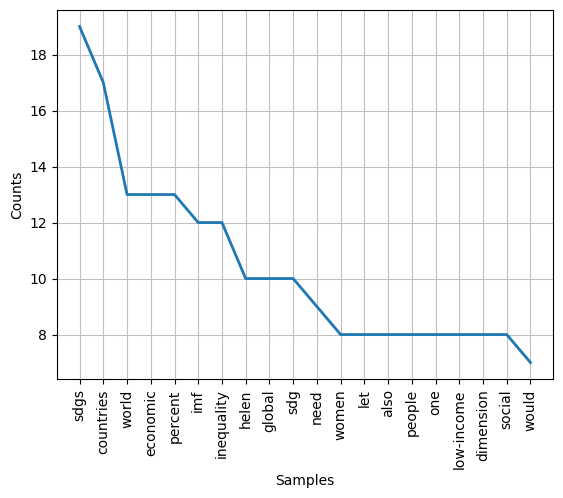

In [41]:
# Your code here:
cleandoc = []

doc = " ".join(document)
words = doc.split()

for word in words:
    word = word.lower().strip(string.punctuation)
    if word != "" and word not in stop_words:
        cleandoc.append(word)

fdist3= FreqDist(cleandoc)
x = fdist3.most_common(20)
print(x)
print(fdist3.plot(20))

Please read the speech. What does the word frequency tell us, if anything, about the speech? Please answer in a short paragraph that tells me how the word frequency distribution is good at finding meaning, but also may miss the meaning that you gained from actually reading the article. 

It is an IMF speech about global SDGs in the context of an obituary about Helen Alexander, so the top words (SDGs, countries, world, economic, percent, imf, inequality, helen, global, sdg) all make sense. I think the biggest thing we lose lies in the simple difference between seeing words but losing the story. Outside of Helen and perhaps IMF, this word graph could describe thousands of speeches. The story that Lagarde tells, however, is one of progress and focuses specifically on key demographics of vulnerable populations. There is also significant depth on each of the 4 dimensions that Lagarde discusses (economic, social, environmental, and governance) - however, the only word represented on this graph is "economic," which comes up frequently outside the context of dimensions. To even see Lagrade's key priorities, one needs the speech itself. There was also a considerable focus on bringing women into the workforce, which is hinted at with 8 instances of the word "women" occurring, but certainly not articulated. While looking at the data I assumed that was in the context of Helen. Being able to see phrases, like "women in the workforce," would provide greater context.

At the same time, we lose external context. We see IMF occur frequently, but don't know who the speaker audience is, and what the speaker's background is.

Finally, we lose tone. These words could equally be railing against the elite or expressing optimism for the future. To better establish her intent without reading the article, I'd invoke sentiment analysis as well.

6. ### Your paragraph here: 





## Other language analysis:

Here is a link to a github repo that contains Donald Trump's speeches: https://github.com/ryanmcdermott/trump-speeches/blob/master/speeches.txt
What are the 10 most common things Donald Trump "loves?"

In [47]:
import re

In [57]:
7. #Your code and answer here:
base_url = 'https://raw.githubusercontent.com/ryanmcdermott/trump-speeches/master/speeches.txt'
r1 = requests.get(base_url)
text = r1.text.lower()

stop_words = set(stopwords.words('english'))
words = text.split()

cleandoc = []
for word in words:
    word = word.strip(string.punctuation)
    if word != "" and word not in stop_words:
        cleandoc.append(word)

fdist = FreqDist(cleandoc)
print("Trump's most common words are:", fdist.most_common(20), "BUT THAT'S NOT WHAT WE'RE LOOKING FOR!!!")

love_words = []

for i in range(len(clean_words) - 1):
    if clean_words[i] in ['love', 'loves']:
        next_word = clean_words[i + 1]
        if next_word != "":
            love_words.append(next_word)

fdist2 = FreqDist(love_words)
print("\nTrump's most common love words are:", fdist2.most_common(20), "BUT WE CAN STILL DO BETTER!!!")

from collections import defaultdict

top_20_love_phrases = [phrase for phrase, count in fdist3.most_common(20)]

sentences = re.split(r'[.!?]\s+', text)

phrase_scores = defaultdict(list)

for sentence in sentences:
    if ' love ' in sentence or ' loves ' in sentence:
        for phrase in top_10_love_phrases:
            if phrase in sentence:
                score = analyzer.polarity_scores(sentence)['compound']
                phrase_scores[phrase].append(score)

average_scores = []

for phrase in top_20_love_phrases:
    scores = phrase_scores[phrase]
    if len(scores) > 0:
        avg_score = sum(scores) / len(scores)
        average_scores.append((phrase, len(scores), avg_score))
    else:
        average_scores.append((phrase, 0, None))

print("\nAverage VADER sentence score for each top love phrase ranked by average sentence sentiment:")
for phrase, count, avg_score in average_scores_sorted:
    print(phrase, "| sentences =", count, "| average compound score =", avg_score)

# I'll leave it at this, but I'm not in love with this left. China being at the top is pretty sus. Also, you, you too, and you all
# should probably be grouped. I expanded for 20 for a slightly better group.

Trump's most common words are: [('going', 2055), ('people', 1328), ('know', 1314), ('–', 1300), ('it’s', 1103), ('we’re', 982), ('don’t', 888), ('said', 771), ('i’m', 769), ('want', 760), ('great', 687), ('they’re', 676), ('get', 632), ('like', 626), ('think', 625), ('one', 588), ('country', 527), ('say', 510), ('right', 501), ('—', 499)] BUT THAT'S NOT WHAT WE'RE LOOKING FOR!!!

Trump's most common love words are: [('try', 1), ('trust', 1), ('much', 1)] BUT WE CAN STILL DO BETTER!!!

Average VADER sentence score for each top love phrase ranked by average sentence sentiment:
china | sentences = 7 | average compound score = 0.7373571428571429
you too | sentences = 5 | average compound score = 0.7354200000000001
mexico | sentences = 7 | average compound score = 0.7283714285714286
me | sentences = 48 | average compound score = 0.7152250000000001
it | sentences = 63 | average compound score = 0.7110015873015874
the people | sentences = 13 | average compound score = 0.7039230769230769
them 

Which are the top 5 countries Trump mentions in his speeches, besides America or the United States of America?

In [63]:
8. #Your code and answer here:
import pycountry

countries = [country.name for country in pycountry.countries]

import requests

base_url = 'https://raw.githubusercontent.com/ryanmcdermott/trump-speeches/master/speeches.txt'
r = requests.get(base_url)
text = r.text
print(text[:2000])

text_lower = text.lower()
countries_lower = [country.lower() for country in countries]

country_counts = {}

for country in countries_lower:
    count = text_lower.count(country)
    if count > 0:
        country_counts[country] = count

sorted_country_counts = sorted(country_counts.items(), key=lambda x: x[1], reverse=True)

for country, count in sorted_country_counts:
    print(country, count)

﻿SPEECH 1


...Thank you so much.  That's so nice.  Isn't he a great guy.  He doesn't get a fair press; he doesn't get it.  It's just not fair.  And I have to tell you I'm here, and very strongly here, because I have great respect for Steve King and have great respect likewise for Citizens United, David and everybody, and tremendous resect for the Tea Party.  Also, also the people of Iowa.  They have something in common.  Hard-working people.  They want to work, they want to make the country great.  I love the people of Iowa.  So that's the way it is.  Very simple.
With that said, our country is really headed in the wrong direction with a president who is doing an absolutely terrible job.  The world is collapsing around us, and many of the problems we've caused.  Our president is either grossly incompetent, a word that more and more people are using, and I think I was the first to use it, or he has a completely different agenda than you want to know about, which could be possible.  In 

https://chatgpt.com/share/69e1ca94-615c-83ea-9f19-0db573eb0696